In [1]:
import kagglehub

# This will prompt you to enter your username and key cleanly
kagglehub.login()

# Try downloading again now that you are explicitly logged in
try:
    path = kagglehub.competition_download('cmi-detect-behavior-with-sensor-data')
    print("Download Complete! Path:", path)
except Exception as e:
    print("Error:", e)


Download Complete! Path: /root/.cache/kagglehub/competitions/cmi-detect-behavior-with-sensor-data


In [2]:
dataset = path+"/train.csv"

In [3]:
import pandas as pd
import os
import kagglehub

df = pd.read_csv(dataset)


In [4]:

df

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574940,SEQ_065531_000048,Non-Target,SEQ_065531,48,SUBJ_039498,Seated Lean Non Dom - FACE DOWN,Performs gesture,Gesture,Write name on leg,3.503906,...,62.0,65.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,71.0
574941,SEQ_065531_000049,Non-Target,SEQ_065531,49,SUBJ_039498,Seated Lean Non Dom - FACE DOWN,Performs gesture,Gesture,Write name on leg,3.773438,...,71.0,72.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
574942,SEQ_065531_000050,Non-Target,SEQ_065531,50,SUBJ_039498,Seated Lean Non Dom - FACE DOWN,Performs gesture,Gesture,Write name on leg,3.082031,...,80.0,77.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
574943,SEQ_065531_000051,Non-Target,SEQ_065531,51,SUBJ_039498,Seated Lean Non Dom - FACE DOWN,Performs gesture,Gesture,Write name on leg,3.964844,...,72.0,77.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [5]:
df.isnull().sum()

,0
row_id,0
sequence_type,0
sequence_id,0
sequence_counter,0
subject,0
...,...
tof_5_v59,30142
tof_5_v60,30142
tof_5_v61,30142
tof_5_v62,30142


In [6]:
print("Total Null Values:", df.isnull().sum().sum())

Total Null Values: 3597807


In [7]:
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])

        else:
            df[col] = df[col].fillna(df[col].median())

print("Remaining Null Values:", df.isnull().sum().sum())

Remaining Null Values: 0


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("Label Encoding Completed")

Label Encoding Completed


In [9]:
df

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,0,1,0,0,73,2,3,1,1,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,1,1,0,1,73,2,3,1,1,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,2,1,0,2,73,2,3,1,1,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,3,1,0,3,73,2,3,1,1,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,4,1,0,4,73,2,3,1,1,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574940,574940,0,8150,48,44,2,2,0,17,3.503906,...,62.0,65.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,71.0
574941,574941,0,8150,49,44,2,2,0,17,3.773438,...,71.0,72.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
574942,574942,0,8150,50,44,2,2,0,17,3.082031,...,80.0,77.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
574943,574943,0,8150,51,44,2,2,0,17,3.964844,...,72.0,77.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


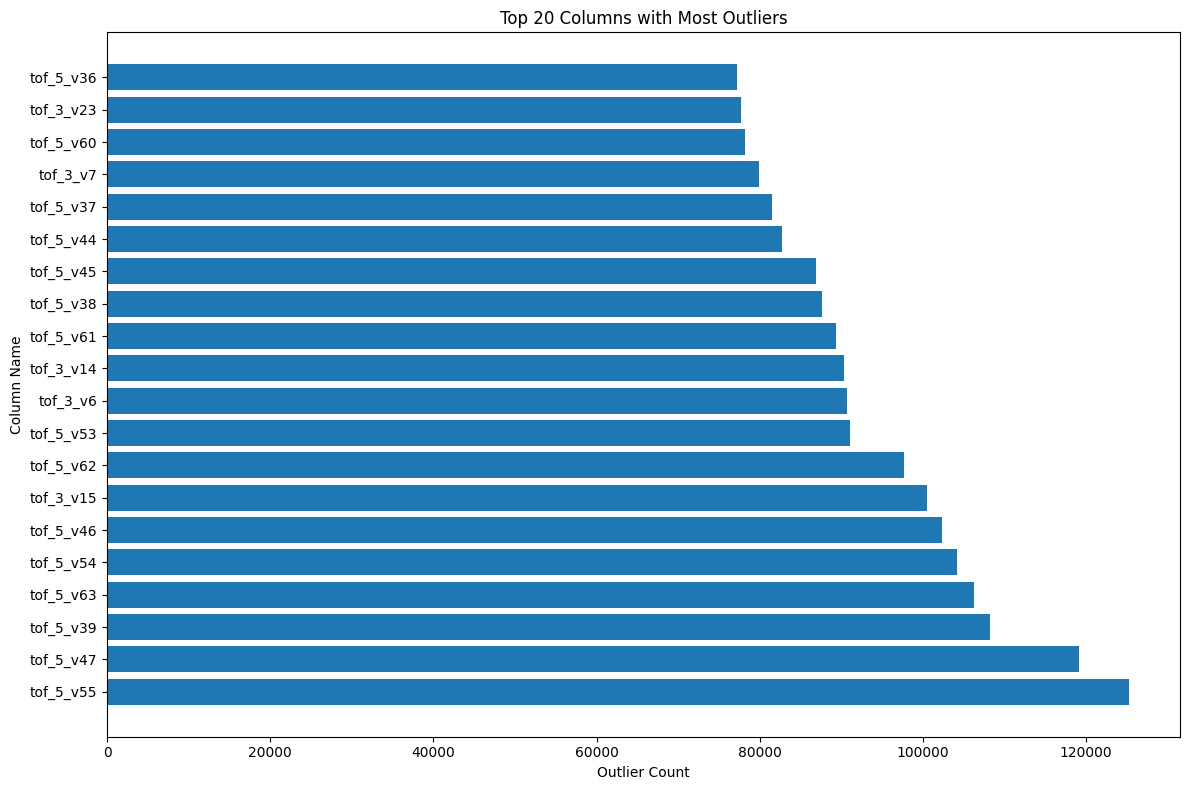

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

outlier_info = []

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if outliers > 0:
        outlier_info.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_info,
    columns=["Column", "Outlier_Count"]
)

top20 = outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))
plt.barh(top20["Column"], top20["Outlier_Count"])
plt.xlabel("Outlier Count")
plt.ylabel("Column Name")
plt.title("Top 20 Columns with Most Outliers")
plt.tight_layout()
plt.show()

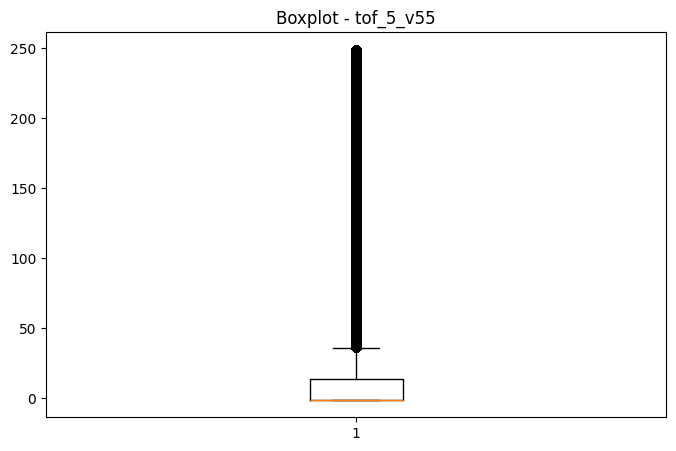

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["tof_5_v55"].dropna())
plt.title("Boxplot - tof_5_v55")
plt.show()

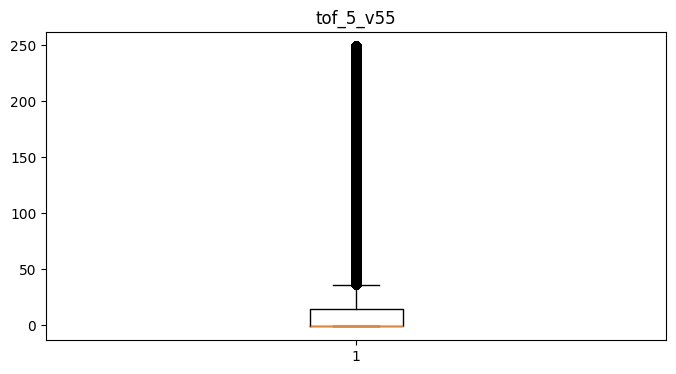

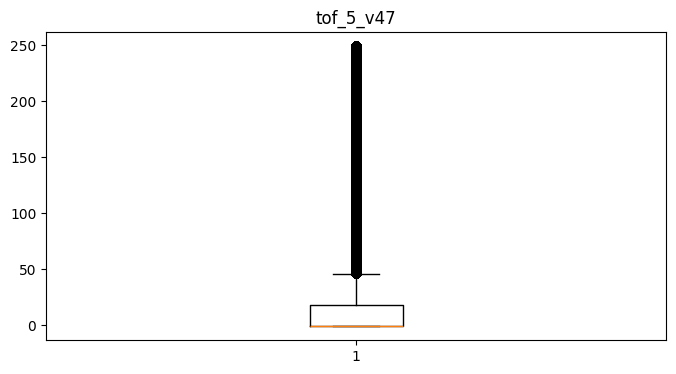

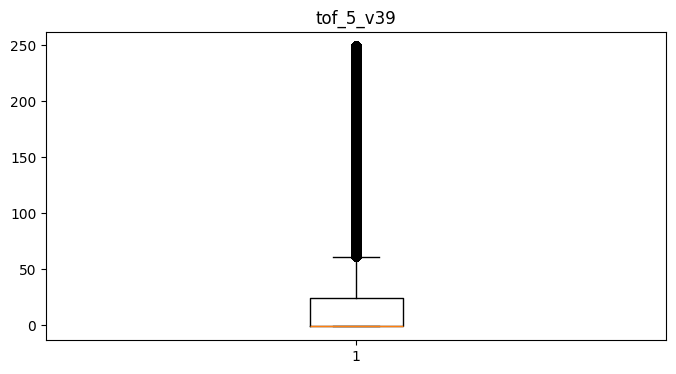

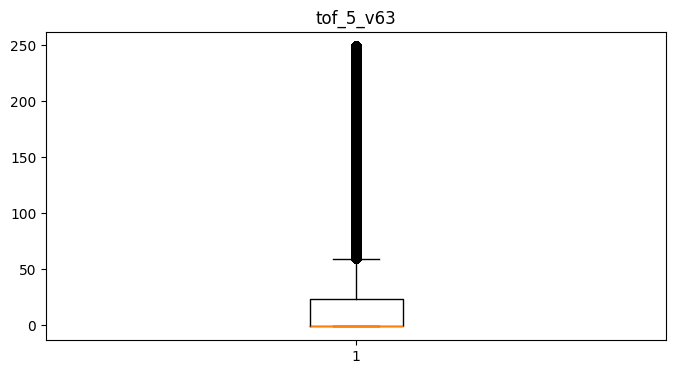

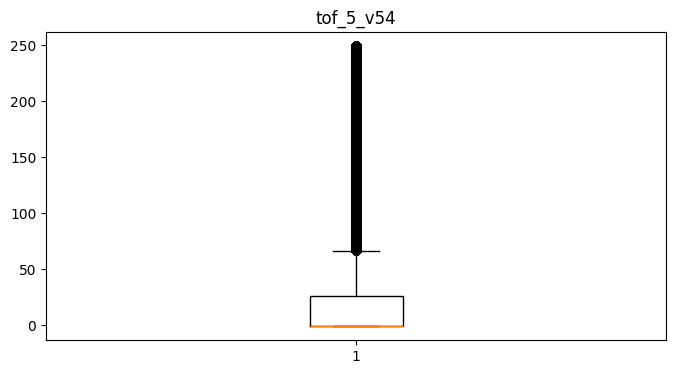

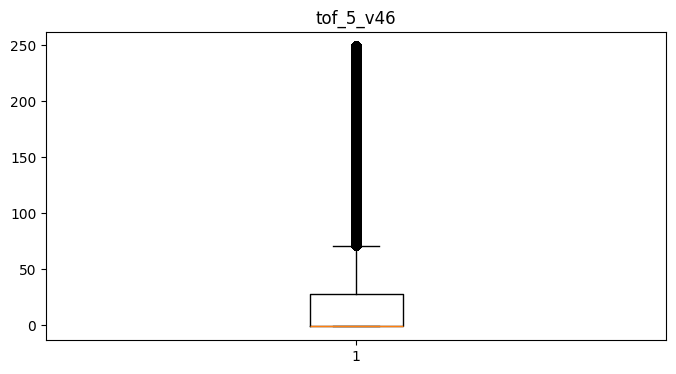

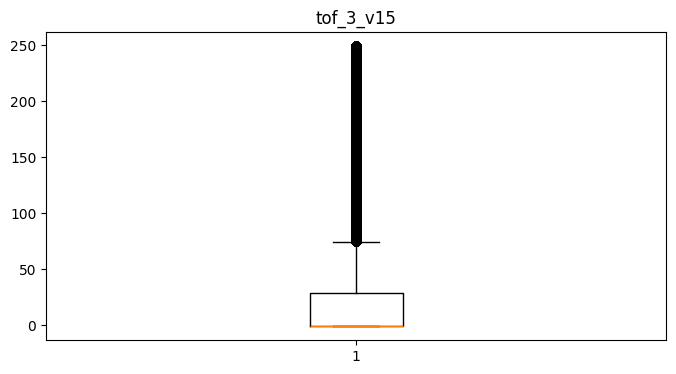

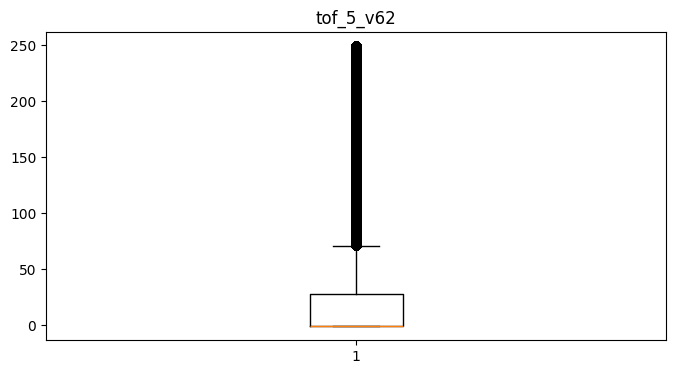

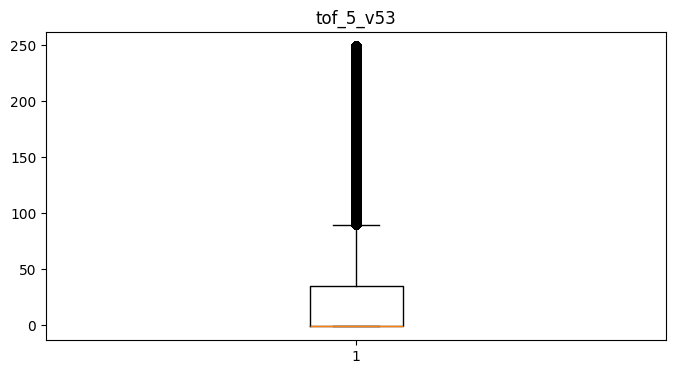

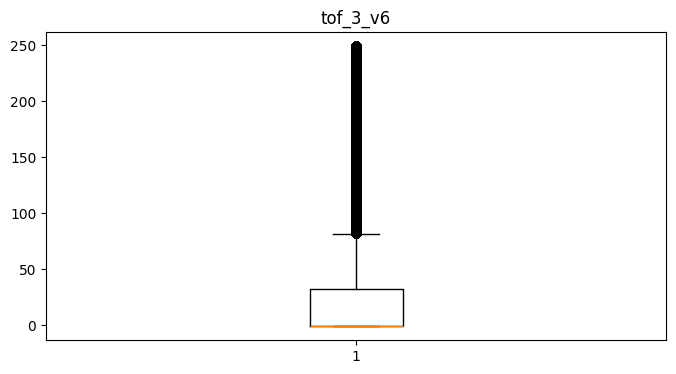

In [12]:
top_cols = outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
)["Column"].head(10)

for col in top_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [13]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outlier Handling Completed")

Outlier Handling Completed


In [14]:
outlier_count = 0

for col in df.select_dtypes(include=np.number).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count += ((df[col] < lower) | (df[col] > upper)).sum()

print("Remaining Outliers:", outlier_count)

Remaining Outliers: 0


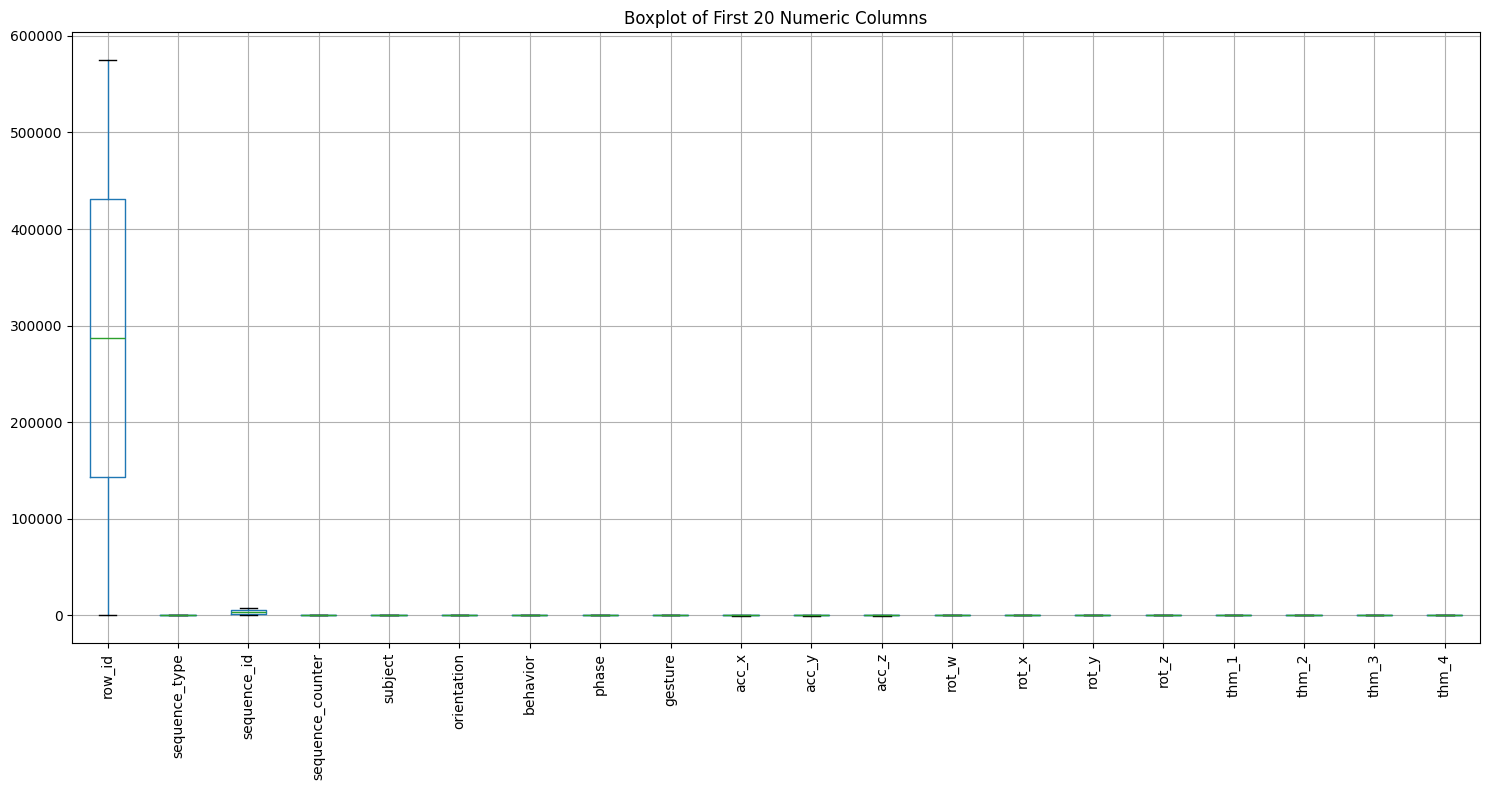

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=np.number).columns[:20]

plt.figure(figsize=(15,8))
df[num_cols].boxplot(rot=90)

plt.title("Boxplot of First 20 Numeric Columns")
plt.tight_layout()
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574945 entries, 0 to 574944
Columns: 341 entries, row_id to tof_5_v63
dtypes: float64(341)
memory usage: 1.5 GB


In [17]:
for col in df.columns:
    print(col, ":", df[col].nunique())

row_id : 574945
sequence_type : 2
sequence_id : 8151
sequence_counter : 111
subject : 81
orientation : 4
behavior : 4
phase : 2
gesture : 18
acc_x : 7805
acc_y : 6458
acc_z : 7879
rot_w : 16018
rot_x : 32568
rot_y : 32720
rot_z : 32317
thm_1 : 435505
thm_2 : 455404
thm_3 : 421684
thm_4 : 375678
thm_5 : 387944
tof_1_v0 : 251
tof_1_v1 : 251
tof_1_v2 : 251
tof_1_v3 : 251
tof_1_v4 : 251
tof_1_v5 : 251
tof_1_v6 : 251
tof_1_v7 : 251
tof_1_v8 : 236
tof_1_v9 : 251
tof_1_v10 : 251
tof_1_v11 : 251
tof_1_v12 : 251
tof_1_v13 : 251
tof_1_v14 : 251
tof_1_v15 : 251
tof_1_v16 : 221
tof_1_v17 : 239
tof_1_v18 : 251
tof_1_v19 : 251
tof_1_v20 : 251
tof_1_v21 : 251
tof_1_v22 : 251
tof_1_v23 : 244
tof_1_v24 : 201
tof_1_v25 : 229
tof_1_v26 : 221
tof_1_v27 : 226
tof_1_v28 : 241
tof_1_v29 : 251
tof_1_v30 : 251
tof_1_v31 : 236
tof_1_v32 : 189
tof_1_v33 : 206
tof_1_v34 : 201
tof_1_v35 : 206
tof_1_v36 : 221
tof_1_v37 : 239
tof_1_v38 : 244
tof_1_v39 : 219
tof_1_v40 : 161
tof_1_v41 : 181
tof_1_v42 : 184
tof_1_v43 :

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


df_small = df.sample(frac=0.25, random_state=42)

y = df_small["gesture"]

X = df_small.drop(
    columns=[
        "gesture",
        "row_id",
        "sequence_id",
        "sequence_counter",
        "subject"
    ],
    errors="ignore"
)

for col in X.select_dtypes(include="object").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = ExtraTreesClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc * 100, 2), "%")

Accuracy : 81.84 %


In [19]:
import joblib

joblib.dump(model, "gesture_lightgbm_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
import joblib

model = joblib.load("gesture_lightgbm_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [21]:
new_pred = model.predict(X_test.iloc[:5])

print(new_pred)

[13. 12.  9. 10.  6.]


In [22]:
import joblib

encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [23]:
joblib.dump(model, "gesture_model.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']